# Exploratory Data Analysis (EDA) – Student Performance Dataset

## Overview

This notebook performs exploratory data analysis (EDA) on the cleaned Student Performance dataset.

The purpose of EDA is to better understand the structure, distributions, relationships, and patterns present within the data before machine learning modeling.

## Objectives

The main goals of this analysis are to:

- Explore the distributions of student-related features
- Identify relationships between variables and exam performance
- Detect trends, correlations, and potential outliers
- Understand which factors may influence academic success
- Support feature engineering and machine learning decisions

## Dataset Description

The dataset contains academic, behavioral, demographic, and lifestyle-related variables such as:

- Hours studied
- Attendance
- Sleep hours
- Previous scores
- Motivation level
- Access to resources
- Family income
- Peer influence
- Exam scores

The dataset was previously cleaned and preprocessed in the data cleaning notebook before being used for this analysis.

## Importance of EDA

Exploratory data analysis is an essential step in the machine learning pipeline because it helps:

- Improve understanding of the dataset
- Validate preprocessing decisions
- Identify important predictive relationships
- Detect imbalances or anomalies
- Guide model selection and feature engineering

The insights generated in this notebook are later used to support the regression modeling and ensemble learning process.

## Importing Libraries

The following libraries are imported for:

- Data manipulation and analysis
- Statistical summaries
- Data visualization
- Correlation analysis

These tools are commonly used in data science workflows for exploratory analysis and machine learning preparation.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

## Loading the Cleaned Dataset

The cleaned dataset generated during preprocessing is loaded into a Pandas DataFrame for exploratory analysis.

This dataset already contains:
- encoded categorical variables
- imputed missing values
- engineered features
- machine-learning-ready numerical data

In [8]:
df = pd.read_csv("CleanedStudentPerformance.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Study_Efficiency
0,23,84,1,3,0,7,73,1,1,0,...,2.0,0,1,3,0,1.0,1.0,1,67,2.875000
1,19,64,1,2,0,8,59,1,1,2,...,2.0,0,-1,4,0,2.0,2.0,0,61,2.111111
2,24,98,2,2,1,7,91,2,1,2,...,2.0,0,0,4,0,3.0,1.0,1,74,3.000000
3,29,89,1,2,1,8,98,2,1,1,...,2.0,0,-1,4,0,1.0,2.0,1,71,3.222222
4,19,92,2,2,1,6,65,2,1,3,...,3.0,0,0,4,0,2.0,1.0,0,70,2.714286


## Dataset Dimensions

The shape of the dataset is examined to determine:

- Number of rows (student records)
- Number of columns (features)

This provides a quick overview of dataset size and complexity.

In [11]:
df.shape

(6607, 21)

## Dataset Structure and Data Types

The dataset structure is inspected to analyze:

- Feature names
- Data types
- Non-null counts
- Dataset consistency

This confirms that the cleaned dataset is fully numerical and ready for analysis and modeling.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   int64  
 1   Attendance                  6607 non-null   int64  
 2   Parental_Involvement        6607 non-null   int64  
 3   Access_to_Resources         6607 non-null   int64  
 4   Extracurricular_Activities  6607 non-null   int64  
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6607 non-null   int64  
 8   Internet_Access             6607 non-null   int64  
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Family_Income               6607 non-null   int64  
 11  Teacher_Quality             6607 non-null   float64
 12  School_Type                 6607 non-null   int64  
 13  Peer_Influence              6607 non-null   

### Dataset Structure Insights

Several important observations can be made from the dataset structure:

- The cleaned dataset contains **6,607 student records** and **21 total features**.
- All variables are now numerical (`int64` or `float64`), meaning the dataset is fully machine-learning ready.
- No object/string columns remain after preprocessing and encoding.
- The engineered feature `Study_Efficiency` was successfully added to the dataset.
- The dataset memory usage is relatively low, making training computationally efficient.
- The successful conversion of categorical variables into numerical representations supports regression-based modeling techniques.

## Descriptive Statistics

Summary statistics are generated to understand the numerical distributions of features in the dataset.

This includes:
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

These statistics help identify variability, central tendencies, and potential outliers.

In [17]:
df.describe()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Study_Efficiency
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000,...,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,2.086423,2.100197,0.596035,7.02906,75.070531,1.906463,0.924474,1.493719,...,2.195247,0.304071,0.190858,2.967610,0.105191,1.696080,1.501589,0.577267,67.235659,2.577849
std,5.990594,11.547475,0.695521,0.698347,0.490728,1.46812,14.399784,0.695798,0.264258,1.230570,...,0.596707,0.460048,0.755876,1.031231,0.306823,0.778897,0.670260,0.494031,3.890456,0.936921
min,1.000000,60.000000,1.000000,1.000000,0.000000,4.00000,50.000000,1.000000,0.000000,0.000000,...,1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,55.000000,0.111111
25%,16.000000,70.000000,2.000000,2.000000,0.000000,6.00000,63.000000,1.000000,1.000000,1.000000,...,2.000000,0.000000,0.000000,2.000000,0.000000,1.000000,1.000000,0.000000,65.000000,1.909091
50%,20.000000,80.000000,2.000000,2.000000,1.000000,7.00000,75.000000,2.000000,1.000000,1.000000,...,2.000000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,67.000000,2.500000
75%,24.000000,90.000000,3.000000,3.000000,1.000000,8.00000,88.000000,2.000000,1.000000,2.000000,...,3.000000,1.000000,1.000000,4.000000,0.000000,2.000000,2.000000,1.000000,69.000000,3.125000
max,44.000000,100.000000,3.000000,3.000000,1.000000,10.00000,100.000000,3.000000,1.000000,8.000000,...,3.000000,1.000000,1.000000,6.000000,1.000000,3.000000,3.000000,1.000000,101.000000,7.600000


### Descriptive Statistics Insights

The descriptive statistics provide several useful insights into the student performance dataset:

- Students studied approximately **20 hours on average**, with some students studying significantly more than others.
- Average attendance was relatively high, close to **80%**, suggesting most students attended classes consistently.
- The average exam score was approximately **67**, with scores ranging from **55 to 101**.
- Most ordinal academic support features (motivation, parental involvement, resources, etc.) were centered around moderate values.
- The engineered `Study_Efficiency` feature displayed meaningful variation across students, supporting its usefulness in later modeling.
- The dataset does not appear to contain extreme numerical instability or unrealistic values, indicating successful preprocessing.

## Final Missing Value Verification

A final missing value check is performed to confirm that preprocessing successfully removed all null values from the dataset.

Machine learning models require complete numerical data for stable training and evaluation.

In [20]:
missing_counts = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": (missing_counts / len(df)) * 100
})

missing_df.sort_values(by="Missing %", ascending=False)

,Missing Count,Missing %
Hours_Studied,0,0.0
Teacher_Quality,0,0.0
Exam_Score,0,0.0
Gender,0,0.0
Distance_from_Home,0,0.0
Parental_Education_Level,0,0.0
Learning_Disabilities,0,0.0
Physical_Activity,0,0.0
Peer_Influence,0,0.0
School_Type,0,0.0


### Missing Value Analysis Insights

The final missing value analysis confirms that the preprocessing pipeline was successful.

Key observations include:

- All features contain **0 missing values**.
- Missing categorical values were successfully imputed during data cleaning.
- The dataset is now complete and suitable for machine learning training and evaluation.
- Removing null values helps improve model stability and prevents training errors.
- The final cleaned dataset maintains consistency across all observations and features.

## Distribution of Exam Scores

The distribution of exam scores is visualized to better understand:

- Common score ranges
- Score concentration
- Potential skewness
- Presence of extreme values or outliers

Understanding the target variable distribution is important for regression modeling and interpretation.

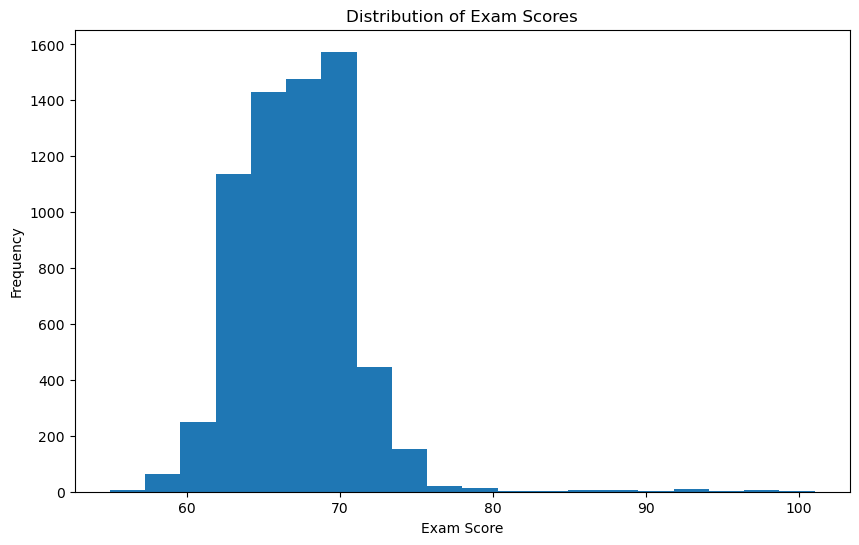

In [23]:
plt.figure(figsize=(10,6))

plt.hist(df["Exam_Score"], bins=20)

plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.title("Distribution of Exam Scores")

plt.show()

### Distribution of Exam Scores Insights

The exam score distribution reveals several important patterns:

- Most student exam scores are concentrated between approximately **60 and 72**.
- The distribution appears moderately centered with a slight right tail caused by high-performing students.
- Extremely high scores above 85 are relatively uncommon, indicating potential outlier behavior.
- The dataset contains fewer elite-performing students compared to average-performing students.
- This distribution later helps explain why the regression model performs strongest within common score ranges while slightly underpredicting rare extreme scores.
- The relatively smooth distribution supports stable regression modeling.

## Relationship Between Hours Studied and Exam Score

This scatterplot examines the relationship between study time and student exam performance.

The goal is to determine whether increased study hours are associated with higher exam scores.

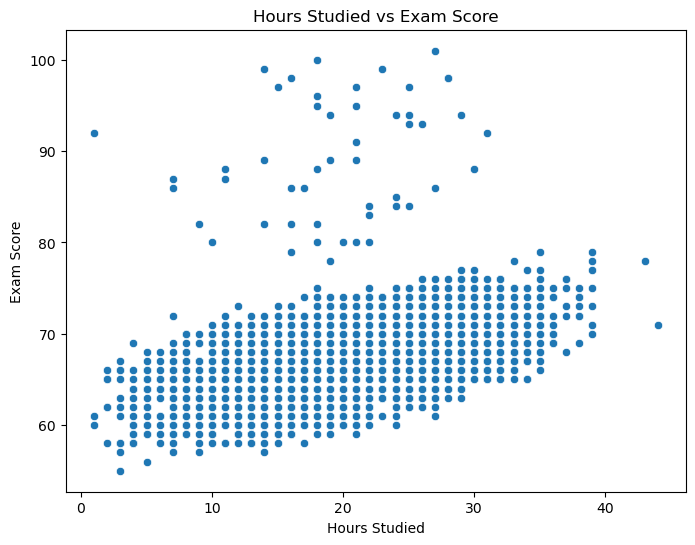

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Hours_Studied"],
    y=df["Exam_Score"]
)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")

plt.show()

### Hours Studied vs Exam Score Insights

This scatterplot demonstrates a positive relationship between study time and academic performance.

Key insights include:

- Students who studied more hours generally achieved higher exam scores.
- The relationship appears moderately linear, supporting the usefulness of this variable for regression modeling.
- High-performing students are more commonly observed among students with higher study durations.
- Some variability still exists, indicating that study hours alone do not fully determine exam success.
- The spread of points suggests that additional behavioral and academic variables also influence performance outcomes.
- This relationship supports the later feature importance results observed in the ensemble model.

## Relationship Between Attendance and Exam Score

This visualization analyzes whether attendance levels are associated with student performance.

Attendance is expected to be an important predictor of academic success.

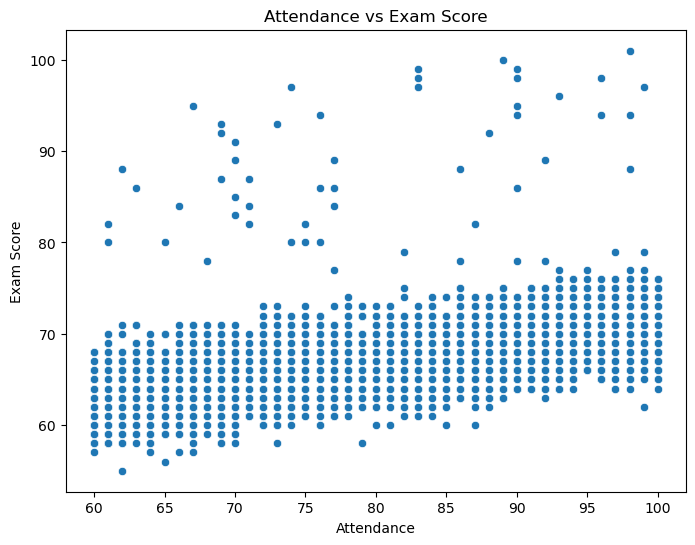

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Attendance"],
    y=df["Exam_Score"]
)

plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")

plt.show()

### Attendance vs Exam Score Insights

Attendance demonstrates one of the strongest visible relationships with exam performance.

Important observations include:

- Higher attendance levels are generally associated with higher exam scores.
- Students with attendance above 85% appear more likely to achieve strong academic performance.
- The upward trend supports the strong positive correlation later observed in the feature importance analysis.
- Attendance appears to be one of the most influential predictors within the dataset.
- While the relationship is not perfectly linear, the overall trend strongly supports its predictive value.
- This finding aligns closely with educational research emphasizing classroom participation and engagement.

## Relationship Between Previous Scores and Current Exam Scores

This graph examines whether previous academic performance is associated with current exam outcomes.

Historical performance often serves as a strong indicator of future achievement.

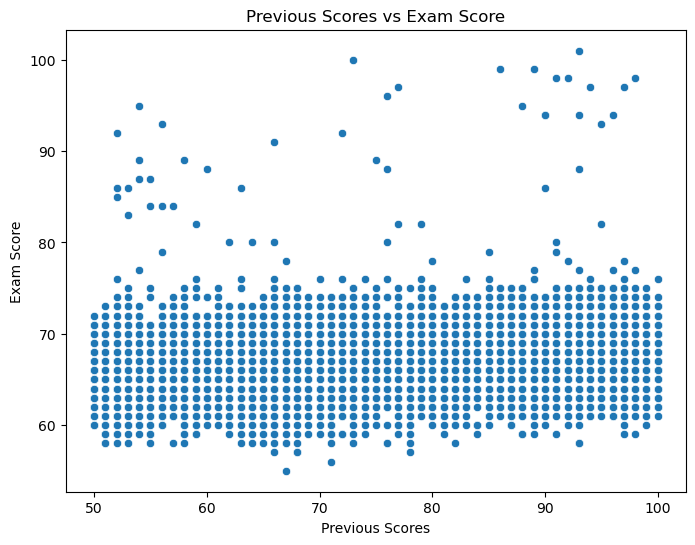

In [38]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Previous_Scores"],
    y=df["Exam_Score"]
)

plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.title("Previous Scores vs Exam Score")

plt.show()

### Previous Scores vs Exam Score Insights

Previous academic performance demonstrates a positive relationship with current exam outcomes.

Key findings include:

- Students with higher previous scores generally tend to achieve higher current exam scores.
- Historical academic performance appears to serve as a useful indicator of future achievement.
- The relationship shows moderate clustering rather than perfect linearity, indicating additional factors influence final performance.
- Several high-performing outliers are present across the graph, representing exceptional student cases.
- The spread of observations suggests that prior performance contributes meaningful predictive information but does not solely determine outcomes.
- This feature later contributed positively within the ensemble learning model.

## Relationship Between Study Efficiency and Exam Score

The engineered `Study_Efficiency` feature is analyzed against exam performance.

This feature was designed to measure how effectively students balance study time and sleep duration.

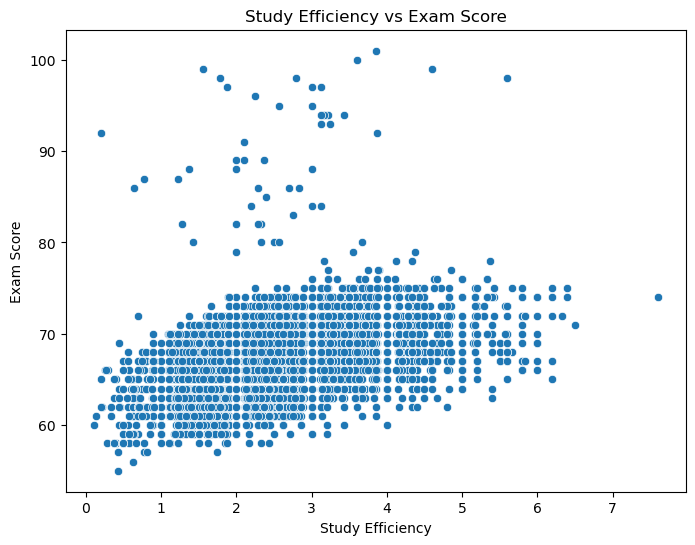

In [41]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Study_Efficiency"],
    y=df["Exam_Score"]
)

plt.xlabel("Study Efficiency")
plt.ylabel("Exam Score")
plt.title("Study Efficiency vs Exam Score")

plt.show()

### Study Efficiency vs Exam Score Insights

The engineered `Study_Efficiency` feature demonstrates a meaningful relationship with exam performance.

Important insights include:

- Students with higher study efficiency generally achieved stronger exam performance.
- The feature successfully captures the balance between study duration and sleep behavior.
- Moderate positive clustering suggests that efficient study habits may contribute to improved outcomes.
- The relationship validates the usefulness of the engineered feature in the machine learning pipeline.
- The spread of points also indicates that study efficiency alone is not sufficient to fully explain student performance.
- This engineered feature later contributed meaningful predictive power within the stacking ensemble model.

## Exam Score Distribution by Parental Involvement

A boxplot is used to compare exam score distributions across different levels of parental involvement.

This helps analyze:
- Median performance
- Score spread
- Variability
- Potential outliers across categories

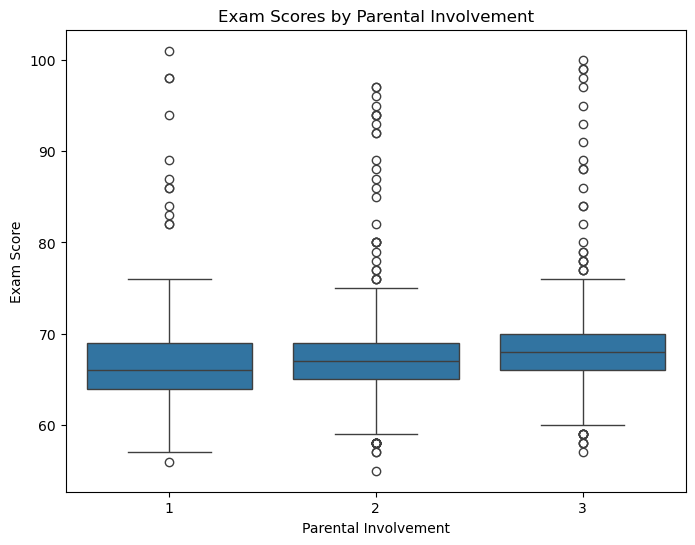

In [44]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x=df["Parental_Involvement"],
    y=df["Exam_Score"]
)

plt.xlabel("Parental Involvement")
plt.ylabel("Exam Score")
plt.title("Exam Scores by Parental Involvement")

plt.show()

### Exam Scores by Parental Involvement Insights

The boxplot reveals noticeable differences in score distributions across parental involvement levels.

Key observations include:

- Higher parental involvement levels are associated with slightly higher median exam scores.
- Students in the highest involvement category demonstrate improved score consistency overall.
- The distribution spread remains relatively similar across groups, suggesting moderate but meaningful influence.
- Multiple high-performing outliers exist across all categories, indicating that exceptional performance can occur regardless of parental involvement level.
- The gradual increase in medians supports the idea that family engagement positively contributes to academic success.
- This variable later demonstrated moderate importance within the ensemble model.

## Average Exam Score by Family Income

This visualization compares average exam performance across family income categories.

The goal is to determine whether economic background may influence academic outcomes.

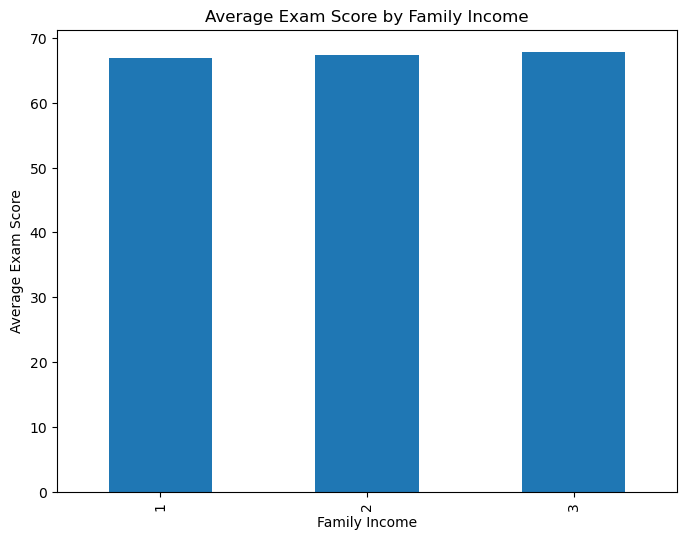

In [47]:
income_scores = df.groupby("Family_Income")["Exam_Score"].mean()

plt.figure(figsize=(8,6))

income_scores.plot(kind="bar")

plt.xlabel("Family Income")
plt.ylabel("Average Exam Score")
plt.title("Average Exam Score by Family Income")

plt.show()

### Average Exam Score by Family Income Insights

The family income analysis shows only small differences in average exam performance across income groups.

Important findings include:

- Average exam scores increase slightly as family income level increases.
- The differences between groups are relatively small compared to behavioral variables such as attendance and study habits.
- Family income may contribute indirectly through access to educational support and resources.
- The relatively small separation between bars suggests that income alone is not a dominant predictor of performance in this dataset.
- Academic behaviors appear to have greater predictive influence than demographic characteristics.

## Average Exam Score by Motivation Level

This chart examines whether student motivation levels are associated with differences in academic performance.

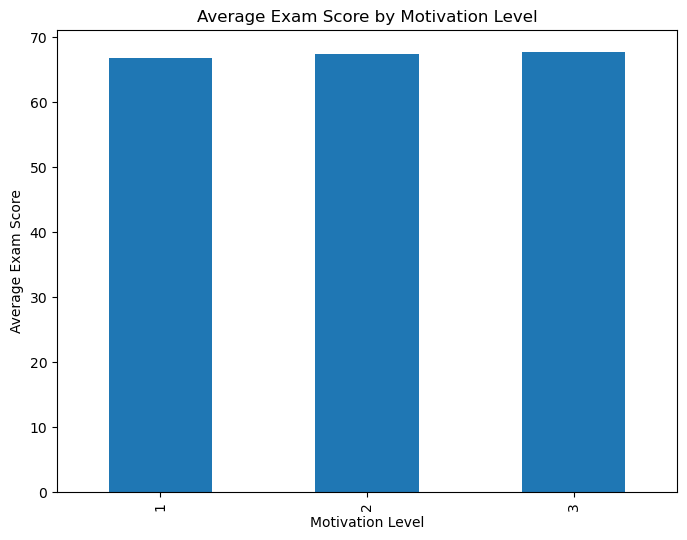

In [50]:
motivation_scores = df.groupby("Motivation_Level")["Exam_Score"].mean()

plt.figure(figsize=(8,6))

motivation_scores.plot(kind="bar")

plt.xlabel("Motivation Level")
plt.ylabel("Average Exam Score")
plt.title("Average Exam Score by Motivation Level")

plt.show()

### Average Exam Score by Motivation Level Insights

Motivation level demonstrates a gradual positive relationship with student performance.

Key insights include:

- Students with higher motivation levels tend to achieve slightly higher average exam scores.
- The increase between categories is consistent, suggesting a meaningful behavioral influence.
- Motivation appears to contribute positively to academic outcomes, although its effect size is smaller than attendance or study hours.
- The relatively close averages indicate that motivation interacts with additional academic and environmental variables.
- This feature still contributed useful predictive information during machine learning modeling.

## Average Exam Score by Access to Resources

This visualization explores the relationship between access to academic resources and student exam performance.

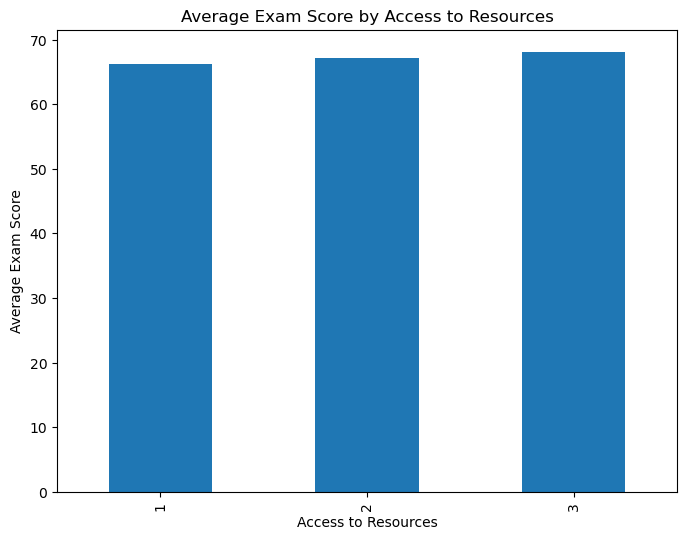

In [53]:
resource_scores = df.groupby("Access_to_Resources")["Exam_Score"].mean()

plt.figure(figsize=(8,6))

resource_scores.plot(kind="bar")

plt.xlabel("Access to Resources")
plt.ylabel("Average Exam Score")
plt.title("Average Exam Score by Access to Resources")

plt.show()

### Average Exam Score by Access to Resources Insights

Access to academic resources appears to positively influence student performance.

Important observations include:

- Students with greater access to educational resources achieved slightly higher average exam scores.
- The upward trend across categories suggests that academic support systems may improve outcomes.
- Although differences are moderate, the relationship remains consistently positive.
- Access to resources likely interacts with study behavior, tutoring, and parental involvement variables.
- This feature later demonstrated meaningful correlation with exam score during model training.

## Features Most Correlated with Exam Score

The features most strongly correlated with exam score are identified to better understand which variables appear most predictive of student performance.

In [56]:
corr_with_target = df.corr()["Exam_Score"].sort_values(ascending=False)

corr_with_target

Exam_Score                    1.000000
Attendance                    0.581072
Hours_Studied                 0.445455
Study_Efficiency              0.377495
Previous_Scores               0.175079
Access_to_Resources           0.169770
Parental_Involvement          0.157114
Tutoring_Sessions             0.156525
Parental_Education_Level      0.103817
Peer_Influence                0.100217
Family_Income                 0.094555
Motivation_Level              0.086937
Teacher_Quality               0.076684
Extracurricular_Activities    0.064382
Internet_Access               0.051475
Physical_Activity             0.027824
School_Type                   0.008844
Gender                       -0.002032
Sleep_Hours                  -0.017022
Learning_Disabilities        -0.085066
Distance_from_Home           -0.088934
Name: Exam_Score, dtype: float64

### Correlation Analysis Insights

The correlation analysis identifies the variables most strongly associated with exam performance.

Key findings include:

- Attendance demonstrated the strongest positive correlation with exam score.
- Hours studied and study efficiency also showed strong positive relationships with academic performance.
- Previous scores, tutoring sessions, parental involvement, and access to resources contributed moderate positive relationships.
- Demographic variables such as gender and school type showed very weak relationships with exam outcomes.
- Sleep hours and learning disabilities showed slight negative relationships with exam score.
- Overall, behavioral and academic support variables were substantially more predictive than demographic characteristics.
- These findings strongly support the feature importance results later observed in the ensemble learning model.

# Exploratory Data Analysis Summary

This exploratory data analysis examined the structure, distributions, relationships, and predictive patterns within the Student Performance dataset.

## Major Findings

### Strong Predictors of Academic Performance

Several academic and behavioral variables demonstrated meaningful relationships with exam score, particularly:

- Attendance
- Hours studied
- Study efficiency
- Previous scores
- Access to resources

Among all variables, attendance appeared to have the strongest relationship with academic success.

### Behavioral Variables Outperformed Demographic Variables

Behavioral and academic support features consistently showed stronger predictive relationships than demographic variables such as:

- Gender
- School type
- Family income

This suggests that student behaviors and educational support systems may influence academic outcomes more heavily than demographic background alone.

### Engineered Features Added Meaningful Information

The engineered `Study_Efficiency` feature successfully captured useful relationships between study habits and exam performance.

This demonstrates the value of feature engineering within the machine learning pipeline.

### Dataset Quality Supported Stable Modeling

The dataset was:
- fully numerical
- free of missing values
- relatively balanced
- computationally efficient

These properties supported stable regression modeling and ensemble learning.

## Overall Conclusion

The exploratory analysis provided valuable insights into:
- student behavior patterns
- score distributions
- influential academic factors
- feature relationships

The findings from this notebook directly supported the later development of the stacking ensemble regression model and helped explain the strong predictive performance achieved during evaluation.